# Import Libraries

In [2]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore")
warnings.filterwarnings( "ignore", module = "pandas\..*" )

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import math
import os
import datetime
from functools import partial
pd.set_option('display.max_columns', None)

from matplotlib import rc
rc('text',usetex=True)
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'
rc('text.latex', preamble='\\usepackage{color} \\usepackage{amsmath} \\usepackage{amssymb}')

In [4]:
from IPython.display import display, HTML
display(HTML("<style>.container { width:80% !important; }</style>"))

In [5]:
DS_name = 'hazelnut'
codes_path = os.getcwd()
results_path=os.path.join(codes_path,         'results')
path_csv    = os.path.join(results_path,          'csv')
path_boxplots    = os.path.join(results_path, 'boxplot')

if os.path.exists(results_path):
    os.makedirs(path_boxplots,              exist_ok=True)


In [6]:
num_epochs = 30000
num_explained_classes = 1
batch_size = 16
num_samples = 500
postfix_csv = f'{DS_name}_9'
exp_name = 'exp_csv_E6'

exp_no = 'E6'


In [7]:
def get_file_modify_time(filepath=None):
    if os.path.exists(filepath):
        datestamp  = datetime.datetime.fromtimestamp(os.path.getmtime(filepath))
        print('File Exists :', filepath)
        print('File Date/Time :', datestamp)

In [8]:
# csv_filename = f'{path_csv}/csv_exp_{postfix_csv}_BPT.csv'
csv_filename = f'{path_csv}/{exp_name}_testresults_{postfix_csv}_BPT_new_eval.csv'
print(csv_filename,' *** ',os.path.exists(csv_filename))

get_file_modify_time(filepath = csv_filename)


e:\Cloud\RashidPHD\Publication_Data\QualITA\notebooks\E6_XAD\results\csv/exp_csv_E6_testresults_hazelnut_9_BPT_new_eval.csv  ***  True
File Exists : e:\Cloud\RashidPHD\Publication_Data\QualITA\notebooks\E6_XAD\results\csv/exp_csv_E6_testresults_hazelnut_9_BPT_new_eval.csv
File Date/Time : 2026-02-05 19:18:11.324609


In [9]:
df = pd.read_csv(csv_filename)
df.head(3)

,Unnamed: 0,a_type_id,a_type,img_no,mask_type,target_segs,num_samples,anomaly_score,anomaly_score_val,AM_roc_score,auroc,max_heatmap,f_S,f_0,f_G,f_B,delta_f,f_T,f_N,method,aucI_pred,aucD_pred,aucI_r,aucD_r,aucI_adj,aucD_adj,aucI_adj_r,aucD_adj_r,aucI_clip,aucI_clipr,aucD_clip,aucD_clipr,threshold,best_point,max_IoU,au_IoU,time_exp,time_aucI,time_aucD,time_IoU,time_total
0,0,0,crack,0,blend_2,100,500,0.552117,173.42245,0.949351,0,0.097862,173.42245,7.260434,55.523064,7.283828,166.16202,0.235855,3,BPT-100,147.812157,16.105082,0.889566,0.096924,147.812157,16.105082,0.889566,0.096924,147.812157,0.889566,16.105082,0.096924,0.069475,0.078491,0.681358,0.195403,2.082480,0.244972,0.236366,0.062511,3.075715
1,1,0,crack,0,blend_2,100,500,0.552117,173.42245,0.949351,0,0.178894,173.42245,7.260434,55.523064,7.283828,166.16202,0.197846,4,BPT-500,150.876565,14.566877,0.908009,0.087667,150.876565,14.566877,0.908009,0.087667,150.876565,0.908009,14.566877,0.087667,0.046827,0.068665,0.779786,0.194305,9.265343,0.466010,0.615621,0.084360,10.880720
2,2,0,crack,0,blend_2,100,500,0.552117,173.42245,0.949351,0,0.221915,173.42245,7.260434,55.523064,7.283828,166.16202,0.197846,4,BPT-1000,151.472874,14.324133,0.911597,0.086206,151.472874,14.324133,0.911597,0.086206,151.472874,0.911597,14.324133,0.086206,0.030308,0.076538,0.711409,0.192212,14.514923,0.435152,0.529823,0.057493,15.986776


In [10]:
computed_method = np.unique(df.method)
num_methods = len(computed_method)
num_images  = len(np.unique(df.img_no))

In [11]:
total_anom_types = np.unique(df.a_type)
total_num_images = 0
for anom_type in total_anom_types:
    images_ls = np.unique(df[df.a_type==anom_type]['img_no'])
    print(anom_type,images_ls)
    total_num_images+=len(images_ls)
print(f'Computing Results for images: \t{total_num_images}')

crack [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17]
cut [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16]
hole [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17]
print [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16]
Computing Results for images: 	70


In [12]:
auc_methods      = [
                    # 'aucI_pred','aucD_pred',\
                    'aucI_clipr' ,'aucD_clipr', \
                    'max_IoU','au_IoU',\
                    'time_exp']

## ANOVA ANALYSIS


In [13]:
from scipy.stats import f_oneway
print('='*108)
print(f'| {"num_images":<20} | {"num_methods":<25} | {"Experiment":53} |')

print(f'| {f"{total_num_images}":<20} | {num_methods:<25} | {exp_no:53} |')

print('='*108)
print(f'| {"METRIC":<20} | {"SIGNIFICANCE":<25} | {"PVALUE":<53} |')
print('-'*108)
methods = sorted(df.method.unique())
for score in auc_methods:
    if score=='time_exp':
        continue
    pops = []
    for m1 in methods:
        pops.append(df[score][df.method==m1].values)
    
    anova = f_oneway(*pops)
    print(f"| {score:<20} | {'H1' if anova.pvalue<0.05 else 'H0':<25} | {anova.pvalue:<53} |")
print('-'*108)

| num_images           | num_methods               | Experiment                                            |
| 70                   | 9                         | E6                                                    |
| METRIC               | SIGNIFICANCE              | PVALUE                                                |
------------------------------------------------------------------------------------------------------------
| aucI_clipr           | H1                        | 4.493185003205885e-22                                 |
| aucD_clipr           | H1                        | 6.332085655415649e-32                                 |
| max_IoU              | H1                        | 4.407638859579677e-58                                 |
| au_IoU               | H0                        | 0.8371551452723229                                    |
------------------------------------------------------------------------------------------------------------


In [14]:
verbose = False
def get_bpt_heatmaps(num_samples=1000,verbose=False):
    pass
def get_aa_heatmaps(num_samples=1000,verbose=False):
    pass
def get_heatmaps_lime(num_samples=1000,verbose=False):
    pass

In [15]:
verbose = False

methods = [
    ('BPT-100',         'xkcd:light pink',      partial(get_bpt_heatmaps, num_samples=100,verbose=verbose)),
    ('BPT-500',         'xkcd:light pink',      partial(get_bpt_heatmaps, num_samples=500,verbose=verbose)),
    ('BPT-1000',         'xkcd:light pink',      partial(get_bpt_heatmaps, num_samples=1000,verbose=verbose)),

    ('AA-100',          'xkcd:bright blue',     partial(get_aa_heatmaps, num_samples=100, verbose=verbose)),
    ('AA-500',          'xkcd:bright blue',     partial(get_aa_heatmaps, num_samples=500, verbose=verbose)),
    ('AA-1000',         'xkcd:bright blue',     partial(get_aa_heatmaps, num_samples=1000, verbose=verbose)),
    
    ('LIME-50',        'xkcd:bright lime',     partial(get_heatmaps_lime, num_segments=50, num_samples=50*5,verbose=verbose)),
    ('LIME-100',        'xkcd:bright lime',     partial(get_heatmaps_lime, num_segments=100, num_samples=100*5,verbose=verbose)),
    ('LIME-200',        'xkcd:bright lime',     partial(get_heatmaps_lime, num_segments=200, num_samples=200*5,verbose=verbose)),
]
for n,_,_ in methods:
    print(n)

BPT-100
BPT-500
BPT-1000
AA-100
AA-500
AA-1000
LIME-50
LIME-100
LIME-200


In [16]:
name_remap = {
    'Partition-100': 'PE-100',
    'Partition-500': 'PE-500',
    'Partition-1000': 'PE-1000',
    'BPT-100': '\\bf BPT-100',
    'BPT-500': '\\bf BPT-500',
    'BPT-1000': '\\bf BPT-1000',
    'aIDG': '$|$IDG$|$',
    'aGradExpl': '$|$GradExpl$|$',
}
method_remap = {
    'max_IoU': '$max$-$IoU$',
    'au_IoU': '$AU$-$IoU$',
    'aucI_pred': '$\\mathit{AUC}^+$',
    'aucD_pred': '$\\mathit{AUC}^-$',
    'aucI_mse': '$\\mathit{MSE}^+$',
    'aucD_mse': '$\\mathit{MSE}^-$',
    'time_exp': 'log(time)'
}
method_colors = {
    'BPT-100':         '#f2a7c0',
    'BPT-500':         '#db587f',
    'BPT-1000':        '#9d2f4d',
    'AA-100':   '#4ed1f9',
    'AA-500':   '#00b1f2',
    'AA-1000':  '#008fe8',
    'AA-5000':  '#006bd7',
    'AA-10000':  '#3245bd',
    'LIME-100':         '#c7e883',
    'LIME-500':        '#8fc543',
    'LIME-1000':        '#66912d',
    'LRP':        '#008080',
    'GradCAM':         'xkcd:camel',
    'aIDG':            '#fcd459',
    'aGradExpl':       '#dd7c2b',
    'ShapGradE':       '#800000',
}
method_symbol = {
    'BPT-100'   :       '$\\clubsuit$1',
    'BPT-500'   :       '$\\clubsuit$2',
    'BPT-1000'  :       '$\\clubsuit$3',
    'AA-100'    :       '$\\boxplus$1',
    'AA-500'    :       '$\\boxplus$2',
    'AA-1000'   :       '$\\boxplus$3',
    'AA-5000'   :       '$\\boxplus$4',
    'AA-10000'  :       '$\\boxplus$5',
    'LIME-100'   :       '\\textbf{0}1',
    'LIME-500'  :      '\\textbf{0}2',
    'LIME-1000'  :      '\\textbf{0}3',
    'LRP'       :      '\\textbf{$\\Pi$}',
    'GradCAM'   :      '$\\bigtriangledown$',
    'aIDG'      :      '$\\divideontimes$',
    'aGradExpl' :     '$\\bigtriangleup$',
     'ShapGradE':       '$\\square$',
}

method_to_shortname = {}
for i,m in enumerate(method_colors.keys()):
    method_to_shortname[m] = f'{method_symbol[m]}'

In [17]:
len(df.img_no[df.a_type==df.a_type.unique()[0]])

162

In [18]:
print(num_methods,computed_method)

9 ['AA-100' 'AA-1000' 'AA-500' 'BPT-100' 'BPT-1000' 'BPT-500' 'LIME-100'
 'LIME-1000' 'LIME-500']


In [19]:
print(f'Total Images: {num_images}')

Total Images: 18


In [20]:
print('Total Time: \t\t',str(datetime.timedelta(seconds=np.sum(df.time_total))))

Total Time: 		 1:37:50.147162


In [21]:
auc_methods      = ['aucI_pred', 'aucD_pred', 'aucI_mse', 'aucD_mse','max_IoU','au_IoU','time_exp']

In [22]:
method_remap = {
    'max_IoU': '$max$-$IoU$',
    'au_IoU': '$AU$-$IoU$',
    'aucI_pred': '$\\mathit{AUC}^+$',
    'aucD_pred': '$\\mathit{AUC}^-$',
    'aucI_adj': '$\\mathit{AUC}^+-Adju$',
    'aucD_adj': '$\\mathit{AUC}^--Adju$',
    
    'aucI_r': '$\\mathit{AUC}^+-R$',
    'aucD_r': '$\\mathit{AUC}^--R$',

    'aucI_adj_r': '$\\mathit{AUC}^+-Adju-R$',
    'aucD_adj_r': '$\\mathit{AUC}^--Adju-R$',


    'aucI_clip': '$\\mathit{AUC}^+-Cl$',
    'aucI_clipr': '$\\mathit{AUC}^+-Cl-R$',

    'aucD_clip': '$\\mathit{AUC}^--Cl$',
    'aucD_clipr': '$\\mathit{AUC}^--Cl-R$',

# aucI_clip, aucI_clipr	aucD_clip aucD_clipr


    'time_exp': 'log(time)'
}

In [23]:
auc_methods      = ['aucI_pred','aucI_clip' , 'aucI_adj' , 'aucI_r', 'aucI_adj_r', 'max_IoU','time_exp',\
                    'aucD_pred','aucD_clipr', 'aucD_adj' , 'aucD_r', 'aucD_adj_r','au_IoU',\
                    ]

auc_method_ascending = ['aucI_pred','aucI_clip','aucI_adj','aucI_r', 'aucI_adj_r''max_IoU', 'au_IoU' ]

In [24]:
df[df['time_total'] == df['time_total'].max()]

,Unnamed: 0,a_type_id,a_type,img_no,mask_type,target_segs,num_samples,anomaly_score,anomaly_score_val,AM_roc_score,auroc,max_heatmap,f_S,f_0,f_G,f_B,delta_f,f_T,f_N,method,aucI_pred,aucD_pred,aucI_r,aucD_r,aucI_adj,aucD_adj,aucI_adj_r,aucD_adj_r,aucI_clip,aucI_clipr,aucD_clip,aucD_clipr,threshold,best_point,max_IoU,au_IoU,time_exp,time_aucI,time_aucD,time_IoU,time_total
80,80,0,crack,8,blend_2,100,500,0.677328,322.71832,0.981862,0,29.740477,322.71832,10.266912,32.570087,10.291439,312.45142,14.842218,9,LIME-1000,288.05034,23.234485,0.921904,0.074362,288.050002,23.234506,0.921903,0.074362,288.050171,0.921904,23.233662,0.074359,2.947371,0.099854,0.677199,0.311033,28.115227,1.870062,2.188071,0.132179,33.012544


In [25]:
threshold = df['time_total'].quantile(0.90)
df_top_90 = df[df['time_total'] > threshold]
df_top_90

,Unnamed: 0,a_type_id,a_type,img_no,mask_type,target_segs,num_samples,anomaly_score,anomaly_score_val,AM_roc_score,auroc,max_heatmap,f_S,f_0,f_G,f_B,delta_f,f_T,f_N,method,aucI_pred,aucD_pred,aucI_r,aucD_r,aucI_adj,aucD_adj,aucI_adj_r,aucD_adj_r,aucI_clip,aucI_clipr,aucD_clip,aucD_clipr,threshold,best_point,max_IoU,au_IoU,time_exp,time_aucI,time_aucD,time_IoU,time_total
17,17,0,crack,1,blend_2,100,500,0.522495,132.811170,0.915270,0,10.215235,132.811170,3.916979,57.964989,3.955309,128.894200,3.837655,11,LIME-1000,113.993682,14.747711,0.884397,0.114417,113.993682,14.747711,0.884397,0.114417,113.993682,0.884397,14.747711,0.114417,2.989501,0.034851,0.253510,0.132268,17.260219,1.116124,1.060935,0.041521,20.225493
26,26,0,crack,2,blend_2,100,500,0.361342,67.723450,0.919574,0,3.663122,67.723450,9.973660,60.706619,10.029914,57.749790,8.684681,11,LIME-1000,46.537166,11.526078,0.805841,0.199586,46.373526,11.526382,0.803008,0.199592,46.455346,0.804424,11.516325,0.199418,0.873330,0.123169,0.059716,0.027605,14.093307,1.025865,1.108999,0.056887,16.943691
35,35,0,crack,3,blend_2,100,500,0.342078,44.854233,0.882456,0,3.439612,44.854233,11.226606,37.696129,11.270423,33.627625,4.858459,12,LIME-1000,29.206070,5.484092,0.868514,0.163083,28.295540,5.484503,0.841437,0.163095,28.750805,0.854976,5.227478,0.155452,1.219135,0.051453,0.156580,0.048583,15.357405,1.402781,1.044737,0.078541,18.575999
44,44,0,crack,4,blend_2,100,500,0.483344,87.945750,0.936997,0,16.076447,87.945750,9.000113,50.004143,9.036057,78.945630,6.012212,14,LIME-1000,68.545993,9.845592,0.868268,0.124714,68.531504,9.845592,0.868085,0.124714,68.538748,0.868177,9.845592,0.124714,4.985058,0.020630,0.758389,0.090410,15.020530,1.236365,1.168807,0.092986,18.249716
53,53,0,crack,5,blend_2,100,500,0.441489,55.830368,0.889899,0,3.229645,55.830368,2.493468,43.222992,2.596626,53.336900,8.573482,13,LIME-1000,45.799805,8.689218,0.858689,0.162912,45.552362,8.689218,0.854050,0.162912,45.676084,0.856369,8.689218,0.162912,2.557260,0.016541,0.074747,0.033908,18.583896,1.568831,1.500766,0.125803,22.401383
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
602,602,3,print,13,blend_2,100,500,0.680435,118.617615,0.945294,0,22.951681,118.617615,3.685117,44.838310,3.714949,114.932495,5.695786,11,LIME-1000,102.089211,11.954598,0.888254,0.104014,102.089211,11.954745,0.888254,0.104015,102.089211,0.888254,11.954217,0.104011,4.987308,0.003540,0.185535,0.049105,14.613168,0.974927,1.150561,0.059983,17.272411
619,619,3,print,15,blend_2,100,500,0.779932,76.840440,0.904456,0,12.140484,76.840440,3.531129,36.192398,3.547533,73.309310,1.586167,9,LIME-500,62.749852,9.708975,0.855960,0.132438,62.749852,9.708975,0.855960,0.132438,62.749852,0.855960,9.708975,0.132438,5.004325,0.001526,0.104418,0.030644,13.875673,0.873084,0.937368,0.062474,16.187440
620,620,3,print,15,blend_2,100,500,0.779932,76.840440,0.904456,0,9.564572,76.840440,3.531129,36.192398,3.547533,73.309310,0.615114,10,LIME-1000,62.047239,10.800899,0.846376,0.147333,62.047239,10.801015,0.846376,0.147335,62.047239,0.846376,10.800293,0.147325,2.550133,0.001038,0.072289,0.026472,13.894189,1.205067,1.028210,0.054941,16.621249
623,623,3,print,16,blend_2,100,500,0.707508,229.407940,0.942142,0,0.670694,229.407940,14.835922,55.976448,14.913616,214.572020,0.126270,3,BPT-1000,199.372904,9.402971,0.929165,0.043822,199.372904,9.402972,0.929165,0.043822,199.372904,0.929165,9.402972,0.043822,0.060881,0.034485,0.671355,0.145673,18.168988,0.923007,0.985972,0.142726,20.865348


## FOR PAPER

In [27]:
method_remap = {
    'max_IoU': '$max$-$IoU$',
    'au_IoU': '$AU$-$IoU$',

    'aucI_clipr': '$\\mathit{AUC}^+$',
    'aucD_clipr': '$\\mathit{AUC}^-$',

    'time_exp': 'log(time)'
}

arrow_up = '$\\Uparrow$'
arrow_down = '$\\Downarrow$'
arrow = {

    'max_IoU': arrow_up,
    'au_IoU': arrow_up,
    'aucI_clipr': arrow_up,
    
    'aucD_clipr': arrow_down,
    'time_exp': arrow_down,
}

FILE SAVED: e:\Cloud\RashidPHD\Publication_Data\QualITA\notebooks\E6_XAD\results\boxplot/results_E6_table_XAD_new.pdf


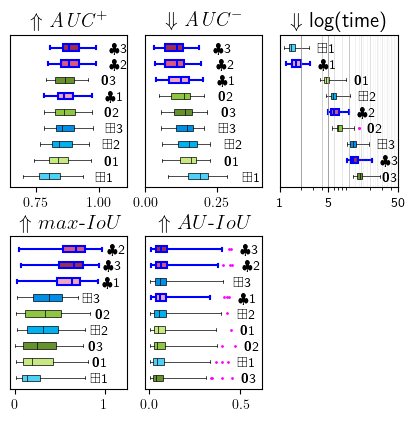

In [59]:
def box_plot(ax, data, label, position, edge_color, line_width, fill_color):
    bp = ax.boxplot(data,
                    labels=[label],
                    # tick_labels=[label],
                    positions=[position], vert=False, 
                    widths=0.4, whis=5, patch_artist=True, flierprops={'markersize': 1, 'markerfacecolor':'magenta', 'markeredgecolor':'magenta'}) # 
    
    for element in ['boxes', 'whiskers', 'fliers', 'means', 'medians', 'caps']:
        plt.setp(bp[element], color=edge_color, linewidth=line_width)

    for patch in bp['boxes']:
        patch.set(facecolor=fill_color)       
        
    return bp

# --- only these metrics, in your requested panel arrangement ---
panel_map = {
    (0, 0): 'aucI_clipr',  # AUC+
    (0, 1): 'aucD_clipr',  # AUC-
    (0, 2): 'time_exp',    # Time
    (1, 0): 'max_IoU',     # Max IoU
    (1, 1): 'au_IoU',      # AU-IoU
}

auc_method_ascending = ['aucI_clipr','aucI_clip','aucI_adj','aucI_r','aucI_adj_r','max_IoU','au_IoU']

fig, axes = plt.subplots(2, 3, figsize=(5, 4.6))  # 2 rows, 3 cols
axes = np.array(axes)

for (r, c), score in panel_map.items():
    ax = axes[r, c]

    ascending = score in auc_method_ascending
    means = df.groupby('method')[[score]].median().sort_values(score, ascending=ascending).index

    log_scale = (score == 'time_exp')
    ax.set_xscale('log' if log_scale else 'linear')

    for i, method in enumerate(means):
        text_yincrement = -0.3

        values = df[df.method == method][score]
        values = values[~values.isna()]

        color = method_colors[method]
        q75 = np.quantile(values, q=0.75)
        q100 = np.quantile(values, q=1.0)

        if not log_scale and 'IoU' not in score and q100 > 1.0:
            q100, text_yincrement = 0.82, 0.15

        box_plot(
            ax,
            [[v for v in values]],
            '',
            i,
            'blue' if method.startswith('BPT') else 'black',
            1.5 if method.startswith('BPT') else 0.5,
            color
        )

        # text placement (keep your existing logic)
        if score in ['aucI_pred', 'aucD_pred']:
            ax.text(min(q100*1.3, 30) if log_scale else q75+0.5, i+text_yincrement, method_to_shortname[method])
        elif score in ['aucI_mse', 'aucD_mse']:
            ax.text(min(q100*1.3, 30) if log_scale else q100+60, i+text_yincrement, method_to_shortname[method])
        else:
            ax.text(min(q100*1.3, 30) if log_scale else q100+0.05, i+text_yincrement, method_to_shortname[method])

    # --- axis limits/ticks per score (your rules) ---
    values_all = df[score]

    if score == 'aucI_clipr':
        min_x, max_x = 0.65, 1.11
    elif score == 'aucD_clipr':
        min_x, max_x = 0, 0.41
    elif score == 'max_IoU':
        min_x, max_x = -0.05, 1.25
    elif score == 'au_IoU':
        min_x, max_x = -0.02, 0.62
    elif score == 'time_exp':
        min_x, max_x = 1, 50
        for m in [2, 5]:
            for k in range(1, max_x):
                ax.axvline(m*k, lw=0.5, color='grey', alpha=1/k)
        ax.set_xticks([1, 5, max_x])
        ax.set_xticklabels(['1', '5', '50'])
    else:
        # fallback
        min_x, max_x = np.nanmin(values_all), np.nanmax(values_all)

    ax.set_xlim(min_x, max_x)

    ax.set_title(f"{arrow[score]} {method_remap[score]}", fontsize=15)
    ax.set_ylim(-0.7, len(means)-1 + 0.8)
    ax.set_yticks([])

# Turn off the unused last panel (row 2 col 3)
axes[1, 2].axis("off")

plt.subplots_adjust(wspace=0.15, hspace=0.32)

# plt.savefig(f'{path_boxplots}/results_{exp_no}_table_XAD_new.pdf', dpi=150, transparent=True,
            # bbox_inches='tight', pad_inches=0.02)
plt.savefig(f'{path_boxplots}/results_{exp_no}_table_XAD_new.svg', dpi=150, transparent=True,
            bbox_inches='tight', pad_inches=0.02)
# plt.savefig(f'{path_boxplots}/results_{exp_no}_table_XAD_new.png', dpi=150, transparent=True,
            # bbox_inches='tight', pad_inches=0.02)

print(f'FILE SAVED: {path_boxplots}/results_{exp_no}_table_XAD_new.pdf')
plt.show()


In [44]:
# get total number of images for each type of anomaly
total_anom_types = np.unique(df.a_type)
total_num_images = 0
for anom_type in total_anom_types:
    images_ls = np.unique(df[df.a_type==anom_type]['img_no'])
    print(anom_type,images_ls)
    total_num_images+=len(images_ls)
print(f'Total Images: \t{total_num_images}')

crack [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17]
cut [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16]
hole [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17]
print [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16]
Total Images: 	70


FILE SAVED: e:\Cloud\RashidPHD\Publication_Data\QualITA\notebooks\E6_XAD\results\boxplot/results_E6_table_XAD.pdf


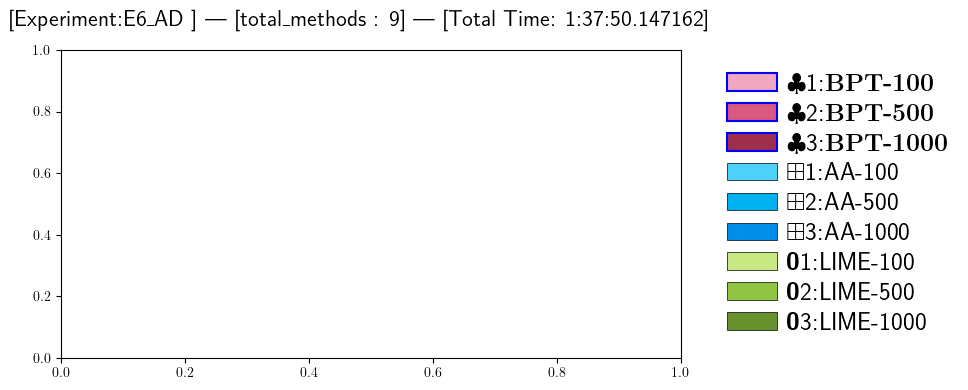

In [45]:
################################
from matplotlib.patches import Patch

plt.figure(figsize=(8, 4))
# last_ax = axes[-1, -1]  # bottom-right subplot

# Unique method list in the order you want
lm = list(df.method.unique())

# Create legend handles with real name + symbol
legend_handles = []
for m in lm:
    shortname = method_to_shortname.get(m, m)
    fullname = name_remap.get(m, m)
    label = f'{shortname}:{fullname}'
    patch = Patch(
        facecolor=method_colors[m],
        edgecolor='blue' if m.startswith('BPT') else 'black',
        linewidth=1.5 if m.startswith('BPT') else 0.5,
        label=label
    )
    legend_handles.append(patch)
# for ti, tl in zip('XAI Methods','NONE'),(total_methods,['NONE']):
#     summary_patch = Patch(facecolor='white', edgecolor='white', label=[ti,tl])
#     legend_handles.append(summary_patch)

# Add legend to bottom-right subplot (split in 2 columns)
plt.legend(
    handles=legend_handles,
    # ncol=9,
    ncol=1,
    loc='center left',
    bbox_to_anchor=(1.05, 0.5),
    fontsize=18,
    frameon=False,
    labelspacing=0.3,      # 👈 vertical gap between items
    handletextpad=0.4,     # 👈 space between patch and text
    columnspacing=0.6,     # 👈 gap between columns
    borderaxespad=0.2      # 👈 padding to axes
)
plt.suptitle(f'[Experiment:{exp_no}_AD ] --- [total_methods : {total_methods}]\
             --- [Total Time: {str(datetime.timedelta(seconds=np.sum(df.time_total)))}]', fontsize=16)
# plt.savefig(f'{path_boxplots}/results_{exp_no}_legend_XAD.pdf', dpi=150, transparent=True, bbox_inches='tight', pad_inches=0.02)
plt.savefig(f'{path_boxplots}/results_{exp_no}_table_XAD.svg', dpi=150, transparent=True, bbox_inches='tight', pad_inches=0.02)
# plt.savefig(f'{path_boxplots}/results_{exp_no}_table_XAD.png', dpi=150, transparent=True, bbox_inches='tight', pad_inches=0.02)
print(f'FILE SAVED: {path_boxplots}/results_{exp_no}_table_XAD.pdf')
plt.show()

# ANOVA
Test statistical significance of the generated data.

- H0: All group means are equal.
- H1: At least one group mean is different from the rest, i.e. score populations are different.

In [30]:
methods = sorted(df.method.unique())
for score in auc_methods:
    pops = []
    for m1 in methods:
        pops.append(df[score][df.method==m1].values)
    
    anova = f_oneway(*pops)
    print('H1' if anova.pvalue<0.05 else 'H0', score,'\t', anova.pvalue)

H1 aucI_clipr 	 4.493185003205885e-22
H1 aucD_clipr 	 6.332085655415649e-32
H1 max_IoU 	 4.407638859579677e-58
H0 au_IoU 	 0.8371551452723229
H1 time_exp 	 8.0890364914879e-288


In [31]:
from scipy.stats import f_oneway
print('='*108)
print(f'| {"num_images":<20} | {"num_methods":<25} | {"Experiment":53} |')

print(f'| {f"{total_num_images}":<20} | {num_methods:<25} | {exp_no:53} |')

print('='*108)
print(f'| {"METRIC":<20} | {"SIGNIFICANCE":<25} | {"PVALUE":<53} |')
print('-'*108)
methods = sorted(df.method.unique())
for score in auc_methods:
    if score=='time_exp':
        continue
    pops = []
    for m1 in methods:
        pops.append(df[score][df.method==m1].values)
    
    anova = f_oneway(*pops)
    print(f"| {score:<20} | {'H1' if anova.pvalue<0.05 else 'H0':<25} | {anova.pvalue:<53} |")
print('-'*108)

| num_images           | num_methods               | Experiment                                            |
| 70                   | 9                         | E6                                                    |
| METRIC               | SIGNIFICANCE              | PVALUE                                                |
------------------------------------------------------------------------------------------------------------
| aucI_clipr           | H1                        | 4.493185003205885e-22                                 |
| aucD_clipr           | H1                        | 6.332085655415649e-32                                 |
| max_IoU              | H1                        | 4.407638859579677e-58                                 |
| au_IoU               | H0                        | 0.8371551452723229                                    |
------------------------------------------------------------------------------------------------------------


In [34]:
df.head(2)

,Unnamed: 0,a_type_id,a_type,img_no,mask_type,target_segs,num_samples,anomaly_score,anomaly_score_val,AM_roc_score,auroc,max_heatmap,f_S,f_0,f_G,f_B,delta_f,f_T,f_N,method,aucI_pred,aucD_pred,aucI_r,aucD_r,aucI_adj,aucD_adj,aucI_adj_r,aucD_adj_r,aucI_clip,aucI_clipr,aucD_clip,aucD_clipr,threshold,best_point,max_IoU,au_IoU,time_exp,time_aucI,time_aucD,time_IoU,time_total
0,0,0,crack,0,blend_2,100,500,0.552117,173.42245,0.949351,0,0.097862,173.42245,7.260434,55.523064,7.283828,166.16202,0.235855,3,BPT-100,147.812157,16.105082,0.889566,0.096924,147.812157,16.105082,0.889566,0.096924,147.812157,0.889566,16.105082,0.096924,0.069475,0.078491,0.681358,0.195403,2.082480,0.244972,0.236366,0.062511,3.075715
1,1,0,crack,0,blend_2,100,500,0.552117,173.42245,0.949351,0,0.178894,173.42245,7.260434,55.523064,7.283828,166.16202,0.197846,4,BPT-500,150.876565,14.566877,0.908009,0.087667,150.876565,14.566877,0.908009,0.087667,150.876565,0.908009,14.566877,0.087667,0.046827,0.068665,0.779786,0.194305,9.265343,0.466010,0.615621,0.084360,10.880720
